# 🧠 Soft Skills Assessment System

This notebook implements a system to assess students' soft skills through interactive quizzes.

## Overview

The assessment system focuses on four key soft skill categories:

- **Communication**: Verbal, written, and interpersonal communication skills
- **Leadership**: Ability to guide, motivate, and manage others
- **Time Management**: Organization, prioritization, and deadline management
- **Analytical Thinking**: Problem-solving, critical thinking, and data analysis

## Approach

1. **Dataset Preparation**: Questions are compiled and categorized under each soft skill (all on 1-5 agreement scale)
2. **Student Assessment**: Students answer questions from each category
3. **Result Visualization**: Students receive visual feedback on their assessment results

In [54]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import plotly.express as px
import warnings
from IPython.display import HTML

warnings.filterwarnings('ignore')

# Define data folder for consistent path usage
data_folder = 'data'
os.makedirs(data_folder, exist_ok=True)  # Create folder if it doesn't exist

# Define file paths for question data files
soft_skills_csv = os.path.join(data_folder, 'all_soft_skills_questions.csv')

print("Data paths initialized.")

Data paths initialized.


## 1. Soft Skills Questions Dataset

In this section, we prepare the dataset of soft skills questions on a 1-5 agreement scale. The questions are categorized under:
- Communication
- Leadership
- Time Management
- Analytical Thinking

Each student will answer these questions, and their responses will be converted to numerical scores for assessment.

In [55]:
# Define soft skill question sources for 1-5 agreement scale format
soft_skills_questions = {
    'communication': {
        'verbal': [
            "I can explain complex topics clearly to people with no background knowledge.",
            "I ensure my message is understood correctly by checking for comprehension.",
            "I handle interruptions during presentations without losing my train of thought.",
            "I adapt my communication style effectively to different types of audiences.",
            "I actively use strategies to improve my listening skills on a regular basis."
        ],
        'written': [
            "I ensure clarity in my written communications by using precise language.",
            "I structure important emails and documents in a logical and organized manner.",
            "I adapt my writing style appropriately for different purposes and audiences.",
            "I thoroughly proofread important written work before finalizing it.",
            "I ensure my written messages convey the intended tone and emotional context."
        ],
        'nonverbal': [
            "I am highly aware of my body language during conversations.",
            "I can accurately interpret others' nonverbal cues during interactions.",
            "My body language consistently matches the verbal message I am communicating.",
            "I effectively adjust my nonverbal communication based on different settings.",
            "I use appropriate eye contact to enhance my communication effectiveness."
        ]
    },
    'leadership': {
        'team_motivation': [
            "I effectively motivate team members who are struggling with their tasks.",
            "I successfully lead teams through challenging situations by providing clear direction.",
            "I use effective strategies to inspire and energize team members.",
            "I recognize and utilize team members' individual strengths in task assignments.",
            "I maintain high team motivation levels even during long-term projects."
        ],
        'decision_making': [
            "I follow a clear process when making important decisions.",
            "I balance input from others with my own judgment when making decisions.",
            "I make effective decisions even under significant time pressure.",
            "I handle making unpopular decisions in a thoughtful and principled manner.",
            "I systematically evaluate the effectiveness of decisions I've made."
        ],
        'responsibility': [
            "I take full responsibility for team outcomes, whether successful or not.",
            "I handle team failures or mistakes constructively and without blame.",
            "I balance delegating tasks with maintaining appropriate oversight.",
            "I effectively encourage accountability in all team members.",
            "I address situations where team members don't meet expectations in a constructive way."
        ]
    },
    'time_management': {
        'prioritization': [
            "I decide which tasks to prioritize effectively when everything seems urgent.",
            "I maintain an organized system for managing tasks and responsibilities.",
            "I balance long-term goals with immediate demands in my planning.",
            "I adapt my priorities smoothly when circumstances change unexpectedly.",
            "I use effective strategies to avoid procrastination on important tasks."
        ],
        'deadline_management': [
            "I meet deadlines consistently across all areas of responsibility.",
            "I handle multiple competing deadlines without becoming overwhelmed.",
            "I take appropriate action promptly when I realize I might miss a deadline.",
            "I set realistic timeframes for my work based on accurate estimates.",
            "I communicate clearly about timeline expectations and any potential changes."
        ],
        'efficiency': [
            "I use effective strategies to work efficiently and maximize productivity.",
            "I minimize distractions successfully during important focused work.",
            "I identify and eliminate time-wasting activities in my schedule.",
            "I strike an appropriate balance between thoroughness and efficiency in my work.",
            "I utilize appropriate tools and systems to manage my time effectively."
        ]
    },
    'analytical': {
        'problem_solving': [
            "I approach complex problems with a clear and effective methodology.",
            "I break down large problems into manageable parts before solving them.",
            "I use effective strategies when I'm stuck on a difficult problem.",
            "I evaluate potential solutions thoroughly before implementation.",
            "I balance analysis with the need for timely action when solving problems."
        ],
        'critical_thinking': [
            "I evaluate the credibility of information using consistent criteria.",
            "I identify biases in my own thinking and adjust my analysis accordingly.",
            "I approach situations with conflicting information in a systematic manner.",
            "I follow a structured process for making evidence-based decisions.",
            "I regularly challenge my own assumptions when analyzing situations."
        ],
        'data_analysis': [
            "I feel comfortable interpreting complex numerical data and statistics.",
            "I identify meaningful patterns and trends in information effectively.",
            "I determine what data is relevant to a decision using clear criteria.",
            "I communicate complex data insights to others in an understandable way.",
            "I consistently use data to support my recommendations and decisions."
        ]
    }
}

# Function to safely save a dataframe to CSV with error handling
def safe_save_csv(df, filepath, description="data"):
    # Ensure directory exists
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    
    try:
        df.to_csv(filepath, index=False)
        print(f"✅ Saved {len(df)} {description} items to {filepath}")
        return True, filepath
    except PermissionError:
        # Try with a timestamp appended
        import time
        timestamp = int(time.time())
        new_path = f"{os.path.splitext(filepath)[0]}_{timestamp}{os.path.splitext(filepath)[1]}"
        try:
            df.to_csv(new_path, index=False)
            print(f"⚠️ Permission error with original path. Saved to {new_path} instead.")
            return True, new_path
        except Exception as e:
            print(f"❌ Failed to save CSV: {e}")
            return False, None

print(f"Defined {sum(len(subcategory) for category in soft_skills_questions.values() for subcategory in category.values())} questions across 4 skill categories")

Defined 60 questions across 4 skill categories


In [56]:
# Compile questions from all categories into a unified dataset
def compile_questions_dataset():
    all_questions = []
    
    for category, subcategories in soft_skills_questions.items():
        for subcategory, questions in subcategories.items():
            for question in questions:
                all_questions.append({
                    'question': question,
                    'category': category
                })
    
    # Create DataFrame
    questions_df = pd.DataFrame(all_questions)
    
    # Save to CSV
    success, saved_path = safe_save_csv(questions_df, soft_skills_csv, "soft skills questions")
    
    return questions_df

# Compile and save the questions dataset
questions_df = compile_questions_dataset()
print(f"Created questions dataset with {len(questions_df)} questions")
display(questions_df.head())

✅ Saved 60 soft skills questions items to data\all_soft_skills_questions.csv
Created questions dataset with 60 questions


,question,category
0,I can explain complex topics clearly to people...,communication
1,I ensure my message is understood correctly by...,communication
2,I handle interruptions during presentations wi...,communication
3,I adapt my communication style effectively to ...,communication
4,I actively use strategies to improve my listen...,communication


## 2. Creating the Assessment Interface

This section defines functions to generate interactive quizzes for assessing soft skills.

In [57]:
# Define get_soft_skills_questions function
def get_soft_skills_questions(category=None, count_needed=5, randomize=True):
    """
    Get soft skills questions for assessment.
    
    Args:
        category (str): Category of soft skills ('communication', 'leadership', 'time_management', 'analytical').
                        If None, returns questions from all categories.
        count_needed (int): Number of questions to return per category
        randomize (bool): Whether to randomize the selection of questions
    
    Returns:
        pd.DataFrame: DataFrame containing the selected questions
    """
    all_questions = []
    
    # Function to get questions from a specific category
    def get_category_questions(cat, subcats_dict, count):
        cat_questions = []
        for subcat, questions in subcats_dict.items():
            for question in questions:
                cat_questions.append({
                    'question': question,
                    'category': cat
                })
        
        # Randomize and select the requested number of questions
        if randomize:
            return random.sample(cat_questions, min(count, len(cat_questions)))
        else:
            return cat_questions[:min(count, len(cat_questions))]
    
    # If a specific category is requested
    if category is not None and category in soft_skills_questions:
        all_questions = get_category_questions(category, soft_skills_questions[category], count_needed)
    else:
        # Get questions from all categories
        for cat, subcats in soft_skills_questions.items():
            cat_questions = get_category_questions(cat, subcats, count_needed)
            all_questions.extend(cat_questions)
    
    # Create DataFrame from the collected questions
    questions_df = pd.DataFrame(all_questions)
    
    print(f"Generated {len(questions_df)} questions for {'all categories' if category is None else category}")
    return questions_df

In [58]:
# Function to create an interactive assessment interface
def create_assessment(questions_df, category):
    """Create an HTML assessment form for the given category and questions"""

    # Create a random ID for this assessment
    assessment_id = f"{category}_{random.randint(1000, 9999)}"

    # Start building the HTML form
    html = f"""
    <div class="assessment-container" style="max-width: 800px; margin: 0 auto; font-family: Arial, sans-serif;">
        <h2 style="color: #000; text-align: center;">{category.replace('_', ' ').title()} Skills Assessment</h2>
        <p style="color: #000;">Rate yourself on each statement from 1 (Strongly Disagree) to 5 (Strongly Agree).</p>
        <form id="{assessment_id}">
            <table style="width: 100%; border-collapse: collapse;">
                <tr style="background-color: #e6f2ff;">
                    <th style="padding: 12px; text-align: left; border-bottom: 1px solid #ddd; color: #000;">Statement</th>
                    <th style="padding: 12px; text-align: center; border-bottom: 1px solid #ddd; color: #000;">1<br><small style="color: #000;">Strongly<br>Disagree</small></th>
                    <th style="padding: 12px; text-align: center; border-bottom: 1px solid #ddd; color: #000;">2<br><small style="color: #000;">Disagree</small></th>
                    <th style="padding: 12px; text-align: center; border-bottom: 1px solid #ddd; color: #000;">3<br><small style="color: #000;">Neutral</small></th>
                    <th style="padding: 12px; text-align: center; border-bottom: 1px solid #ddd; color: #000;">4<br><small style="color: #000;">Agree</small></th>
                    <th style="padding: 12px; text-align: center; border-bottom: 1px solid #ddd; color: #000;">5<br><small style="color: #000;">Strongly<br>Agree</small></th>
                </tr>
    """

    # Add each question as a row in the table
    for i, row in questions_df.iterrows():
        question_id = f"q_{i}"
        question_text = row['question']

        html += f"""
        <tr style="border-bottom: 1px solid #ddd;">
            <td style="padding: 12px;">{question_text}</td>
        """

        # Add radio buttons for each rating option
        for rating in range(1, 6):
            html += f"""
            <td style="text-align: center;">
                <input type="radio" name="{question_id}" value="{rating}" required>
            </td>
            """

        html += "</tr>"

    # Add submit button and closing tags
    html += f"""
            </table>
            <div style="margin-top: 40px; margin-bottom: 60px; text-align: center; background-color: white; padding: 15px; border-radius: 8px;">
                <button type="button" id="submit-btn-{assessment_id}" style="background-color: #4CAF50; color: white; padding: 15px 30px; border: 2px solid black; border-radius: 4px; cursor: pointer; font-size: 18px; font-weight: bold; box-shadow: 0 4px 8px rgba(0,0,0,0.2);">SUBMIT ASSESSMENT</button>
            </div>
        </form>
        <div id="results-{assessment_id}" style="margin-top: 20px; display: none;">
            <h3>Your Results</h3>
            <div id="score-{assessment_id}"></div>
            <div id="feedback-{assessment_id}"></div>
        </div>
        <script>
        document.getElementById("submit-btn-{assessment_id}").addEventListener("click", function() {{
            // Simple scoring logic
            let form = document.getElementById("{assessment_id}");
            let total = 0;
            let answered = 0;
            let questions = {len(questions_df)};

            for (let i = 0; i < questions; i++) {{
                let name = "q_" + i;
                let selected = document.querySelector('input[name="' + name + '"]:checked');
                if (selected) {{
                    total += parseInt(selected.value);
                    answered++;
                }}
            }}

            if (answered < questions) {{
                alert("Please answer all questions before submitting.");
                return;
            }}

            let average = total / questions;
            let percentage = (average / 5) * 100;

            // Display results
            document.getElementById("score-{assessment_id}").innerHTML = '<p>Your average score: <strong>' + average.toFixed(1) + '/5</strong> (' + percentage.toFixed(1) + '%)</p>';

            // Generate feedback based on score
            let feedback = '';
            if (average >= 4.5) {{
                feedback = 'Outstanding! You demonstrate excellent {category.replace('_', ' ')} skills.';
            }} else if (average >= 3.5) {{
                feedback = 'Good job! You have solid {category.replace('_', ' ')} skills with some room for improvement.';
            }} else if (average >= 2.5) {{
                feedback = 'You have moderate {category.replace('_', ' ')} skills. Consider focusing on development in this area.';
            }} else {{
                feedback = 'This appears to be an area for growth. Consider seeking resources to develop your {category.replace('_', ' ')} skills.';
            }}

            document.getElementById("feedback-{assessment_id}").innerHTML = '<p>' + feedback + '</p>';
            document.getElementById("results-{assessment_id}").style.display = "block";
        }});
        </script>
    </div>
    """

    return HTML(html)

## 3. Generate Assessment for Each Soft Skill Category

In this section, we create assessments for each soft skill category.

In [59]:
# Example: Create an assessment for Communication skills
communication_questions = get_soft_skills_questions('communication', count_needed=10)
create_assessment(communication_questions, 'communication')

Generated 10 questions for communication


Statement,1StronglyDisagree,2Disagree,3Neutral,4Agree,5StronglyAgree
I ensure my message is understood correctly by checking for comprehension.,,,,,
I actively use strategies to improve my listening skills on a regular basis.,,,,,
I ensure clarity in my written communications by using precise language.,,,,,
I can explain complex topics clearly to people with no background knowledge.,,,,,
I handle interruptions during presentations without losing my train of thought.,,,,,
I can accurately interpret others' nonverbal cues during interactions.,,,,,
I am highly aware of my body language during conversations.,,,,,
I use appropriate eye contact to enhance my communication effectiveness.,,,,,
My body language consistently matches the verbal message I am communicating.,,,,,
I thoroughly proofread important written work before finalizing it.,,,,,


In [60]:
# Example: Create an assessment for Leadership skills
leadership_questions = get_soft_skills_questions('leadership', count_needed=10)
create_assessment(leadership_questions, 'leadership')

Generated 10 questions for leadership


Statement,1StronglyDisagree,2Disagree,3Neutral,4Agree,5StronglyAgree
I maintain high team motivation levels even during long-term projects.,,,,,
I recognize and utilize team members' individual strengths in task assignments.,,,,,
I use effective strategies to inspire and energize team members.,,,,,
I effectively encourage accountability in all team members.,,,,,
I handle team failures or mistakes constructively and without blame.,,,,,
I handle making unpopular decisions in a thoughtful and principled manner.,,,,,
I balance input from others with my own judgment when making decisions.,,,,,
I systematically evaluate the effectiveness of decisions I've made.,,,,,
I follow a clear process when making important decisions.,,,,,
I make effective decisions even under significant time pressure.,,,,,


In [61]:
# Example: Create an assessment for Time Management skills
time_management_questions = get_soft_skills_questions('time_management', count_needed=10)
create_assessment(time_management_questions, 'time_management')

Generated 10 questions for time_management


Statement,1StronglyDisagree,2Disagree,3Neutral,4Agree,5StronglyAgree
I meet deadlines consistently across all areas of responsibility.,,,,,
I communicate clearly about timeline expectations and any potential changes.,,,,,
I use effective strategies to avoid procrastination on important tasks.,,,,,
I adapt my priorities smoothly when circumstances change unexpectedly.,,,,,
I balance long-term goals with immediate demands in my planning.,,,,,
I handle multiple competing deadlines without becoming overwhelmed.,,,,,
I use effective strategies to work efficiently and maximize productivity.,,,,,
I set realistic timeframes for my work based on accurate estimates.,,,,,
I identify and eliminate time-wasting activities in my schedule.,,,,,
I take appropriate action promptly when I realize I might miss a deadline.,,,,,


In [62]:
# Example: Create an assessment for Analytical skills
analytical_questions = get_soft_skills_questions('analytical', count_needed=10)
create_assessment(analytical_questions, 'analytical')

Generated 10 questions for analytical



Statement,1StronglyDisagree,2Disagree,3Neutral,4Agree,5StronglyAgree
I use effective strategies when I'm stuck on a difficult problem.,,,,,
I balance analysis with the need for timely action when solving problems.,,,,,
I regularly challenge my own assumptions when analyzing situations.,,,,,
I identify meaningful patterns and trends in information effectively.,,,,,
I feel comfortable interpreting complex numerical data and statistics.,,,,,
I evaluate potential solutions thoroughly before implementation.,,,,,
I approach situations with conflicting information in a systematic manner.,,,,,
I consistently use data to support my recommendations and decisions.,,,,,
I determine what data is relevant to a decision using clear criteria.,,,,,
I communicate complex data insights to others in an understandable way.,,,,,


## 4. Create a Comprehensive Soft Skills Assessment

This section combines questions from all categories to create a comprehensive assessment.

In [63]:
# Create a comprehensive assessment with questions from all categories
all_category_questions = get_soft_skills_questions(category=None, count_needed=5)
create_assessment(all_category_questions, 'comprehensive')

Generated 20 questions for all categories


Statement,1StronglyDisagree,2Disagree,3Neutral,4Agree,5StronglyAgree
I can accurately interpret others' nonverbal cues during interactions.,,,,,
I actively use strategies to improve my listening skills on a regular basis.,,,,,
I use appropriate eye contact to enhance my communication effectiveness.,,,,,
I thoroughly proofread important written work before finalizing it.,,,,,
I ensure clarity in my written communications by using precise language.,,,,,
I use effective strategies to inspire and energize team members.,,,,,
I successfully lead teams through challenging situations by providing clear direction.,,,,,
I address situations where team members don't meet expectations in a constructive way.,,,,,
I balance input from others with my own judgment when making decisions.,,,,,
I effectively motivate team members who are struggling with their tasks.,,,,,


## 5. Visualizing Assessment Results

This section demonstrates how to visualize soft skills assessment results.

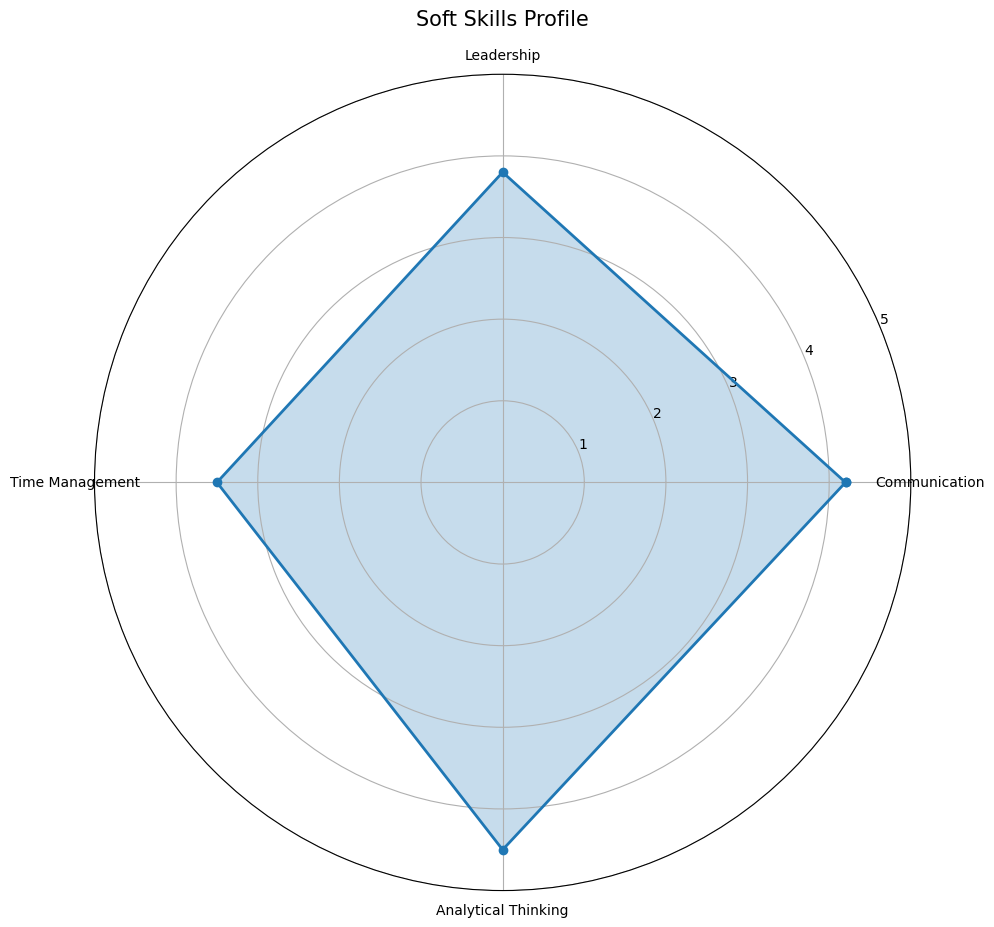

In [64]:
# Function to visualize soft skills profile
def visualize_soft_skills_profile(scores):
    """
    Create a radar chart to visualize a student's soft skills profile.
    
    Args:
        scores (dict): Dictionary with categories as keys and scores (1-5) as values
    """
    categories = list(scores.keys())
    values = list(scores.values())
    
    # Create the plot
    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    # Set the angles for each category
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    
    # Ensure we close the radar chart by repeating the first value
    values.append(values[0])
    categories.append(categories[0])
    angles += angles[:1]  # Close the loop
    
    # Plot the values
    ax.plot(angles, values, 'o-', linewidth=2, label='Your Skills')
    ax.fill(angles, values, alpha=0.25)
    
    # Set the labels and styling
    ax.set_thetagrids(np.degrees(angles[:-1]), categories[:-1])
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'])
    ax.set_title('Soft Skills Profile', size=15, y=1.05)
    
    plt.tight_layout()
    plt.show()
    
# Example usage
example_scores = {
    'Communication': 4.2,
    'Leadership': 3.8,
    'Time Management': 3.5,
    'Analytical Thinking': 4.5
}

visualize_soft_skills_profile(example_scores)

## 6. Saving and Loading Assessment Results

This section shows how to save assessment results and load them for analysis.

In [65]:
# Example function to save a student's assessment results
def save_assessment_results(student_id, student_name, scores):
    """
    Save a student's assessment results to CSV.
    
    Args:
        student_id (str): Unique identifier for the student
        student_name (str): Student's name
        scores (dict): Dictionary with categories as keys and scores as values
    """
    # Create a DataFrame for the student results
    results_data = {
        'student_id': [student_id],
        'student_name': [student_name]
    }
    
    # Add each score category
    for category, score in scores.items():
        results_data[f'{category.lower()}_score'] = [score]
    
    # Calculate overall score
    results_data['overall_score'] = [sum(scores.values()) / len(scores)]
    
    # Create DataFrame
    results_df = pd.DataFrame(results_data)
    
    # Define file path
    results_file = os.path.join(data_folder, 'assessment_results.csv')
    
    # Check if file exists to append or create new
    if os.path.exists(results_file):
        # Append to existing file
        existing_df = pd.read_csv(results_file)
        updated_df = pd.concat([existing_df, results_df], ignore_index=True)
        updated_df.to_csv(results_file, index=False)
        print(f"Results for {student_name} appended to {results_file}")
    else:
        # Create new file
        results_df.to_csv(results_file, index=False)
        print(f"New results file created at {results_file} with data for {student_name}")
    
    return results_file

# Example usage
save_assessment_results(
    student_id="STU001",
    student_name="John Doe",
    scores={
        'Communication': 4.2,
        'Leadership': 3.8,
        'Time Management': 3.5,
        'Analytical': 4.5
    }
)

New results file created at data\assessment_results.csv with data for John Doe


'data\\assessment_results.csv'

Loaded 1 assessment results


,student_id,student_name,communication_score,leadership_score,time management_score,analytical_score,overall_score
0,STU001,John Doe,4.2,3.8,3.5,4.5,4.0



Summary Statistics:


,communication_score,leadership_score,time management_score,analytical_score,overall_score
count,1.0,1.0,1.0,1.0,1.0
mean,4.2,3.8,3.5,4.5,4.0
std,NaN,NaN,NaN,NaN,NaN
min,4.2,3.8,3.5,4.5,4.0
25%,4.2,3.8,3.5,4.5,4.0
50%,4.2,3.8,3.5,4.5,4.0
75%,4.2,3.8,3.5,4.5,4.0
max,4.2,3.8,3.5,4.5,4.0


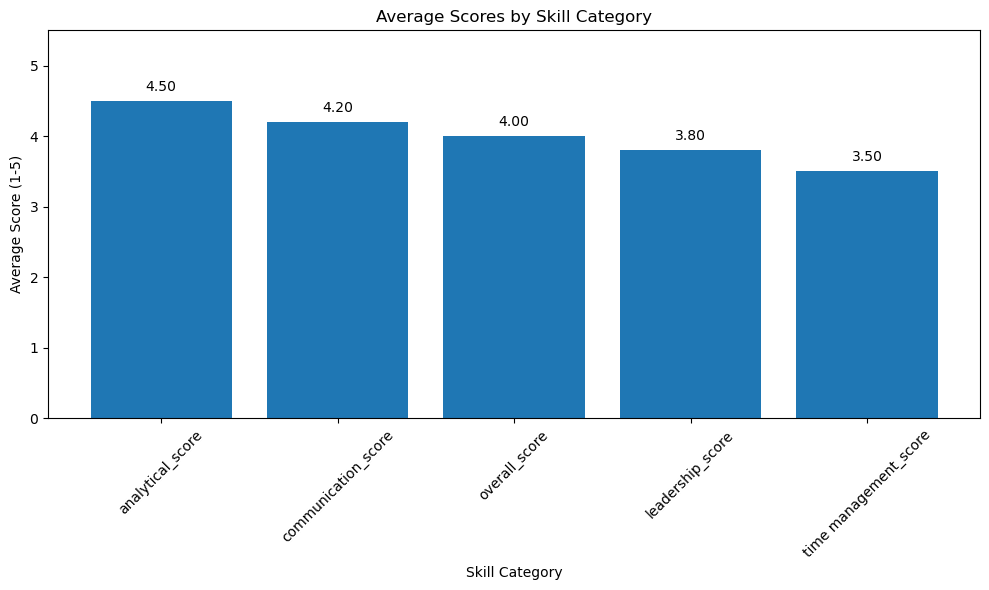

In [66]:
# Function to load and display assessment results
def load_assessment_results():
    """
    Load assessment results and display summary statistics
    """
    results_file = os.path.join(data_folder, 'assessment_results.csv')
    
    if os.path.exists(results_file):
        # Load the results
        results_df = pd.read_csv(results_file)
        print(f"Loaded {len(results_df)} assessment results")
        
        # Display the results
        display(results_df)
        
        # Show summary statistics
        print("\nSummary Statistics:")
        skill_columns = [col for col in results_df.columns if col.endswith('_score')]
        display(results_df[skill_columns].describe())
        
        # Create a bar chart of average scores
        avg_scores = results_df[skill_columns].mean().sort_values(ascending=False)
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(avg_scores.index, avg_scores.values)
        
        # Add value labels on top of each bar
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height:.2f}', ha='center', va='bottom')
        
        plt.ylim(0, 5.5)  # Set y-axis limit
        plt.title('Average Scores by Skill Category')
        plt.xlabel('Skill Category')
        plt.ylabel('Average Score (1-5)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        return results_df
    else:
        print(f"No results file found at {results_file}")
        return None

# Load and display results
results_data = load_assessment_results()

## 7. Main Execution

This section runs the entire assessment generation pipeline:
1. Collects questions for each skill category
2. Saves the questions to CSV files for future use
3. Creates a mixed assessment with questions from all categories
4. Displays the assessment for immediate use

In [67]:
# Main execution section
if __name__ == "__main__":
    import os
    import time
    import pandas as pd
    from IPython.display import HTML
    
    # Ensure the data directory exists
    data_folder = 'data'
    os.makedirs(data_folder, exist_ok=True)
    
    # Get questions for all categories
    all_questions = {}
    # Calculate how many questions we need per category to get ~150 total questions
    # We have 4 categories, so ~38 questions per category to get ~152 total
    questions_per_category = 38
    
    for category in ['communication', 'leadership', 'time_management', 'analytical']:
        print(f"\n--- Processing {category} skills questions ---\n")

        # Get questions for this category
        all_questions[category] = get_soft_skills_questions(
            category=category,
            count_needed=questions_per_category, # Approximately 38 questions per category
            randomize=True
        )

    # Save all questions to CSV files with error handling
    output_files = {}
    for category, df in all_questions.items():
        # Define file paths
        file_path = os.path.join(data_folder, f"{category}_questions.csv")
        
        # Try to save the file with error handling
        try:
            print(f"Attempting to save {len(df)} {category} questions to {file_path}...")
            df.to_csv(file_path, index=False)
            print(f"✅ Successfully saved {category} questions to {file_path}")
            output_files[category] = file_path
        except PermissionError:
            print(f"❌ Permission error when saving to {file_path}")
            
            # Try alternative path with timestamp
            alt_path = os.path.join(data_folder, f"{category}_questions_{int(time.time())}.csv")
            try:
                print(f"Trying alternative path: {alt_path}")
                df.to_csv(alt_path, index=False)
                print(f"✅ Successfully saved to {alt_path}")
                output_files[category] = alt_path
            except Exception as e:
                print(f"❌ Failed to save {category} questions: {str(e)}")
                print("Will continue with other categories...")

    # Save combined questions with error handling
    if all_questions:
        combined_df = pd.concat([df for df in all_questions.values()], ignore_index=True)
        
        # Original combined path
        combined_path = os.path.join(data_folder, "all_soft_skills_questions.csv")
        
        # Alternative paths if original fails
        alternative_paths = [
            os.path.join(data_folder, f"all_soft_skills_questions_{int(time.time())}.csv"),  # Timestamp
            os.path.join(os.getcwd(), "all_soft_skills_questions.csv"),  # Current directory
            os.path.join(data_folder, "combined_soft_skills_questions.csv")  # Different name
        ]
        
        # Try to save to original path first
        try:
            print(f"\nAttempting to save {len(combined_df)} combined questions to {combined_path}...")
            combined_df.to_csv(combined_path, index=False)
            print(f"✅ Successfully saved combined questions to {combined_path}")
            final_output_path = combined_path
        except PermissionError:
            print(f"❌ Permission error when saving to {combined_path}")
            
            # Try alternative paths
            final_output_path = None
            for alt_path in alternative_paths:
                try:
                    print(f"Trying alternative path: {alt_path}")
                    combined_df.to_csv(alt_path, index=False)
                    print(f"✅ Successfully saved to {alt_path}")
                    final_output_path = alt_path
                    break
                except Exception as e:
                    print(f"❌ Failed to save to {alt_path}: {str(e)}")
            
            if not final_output_path:
                print("⚠️ Could not save combined questions to any location.")
                print("You can manually export the DataFrame if needed.")
        
        # Display success message if saved
        if final_output_path:
            file_size = os.path.getsize(final_output_path) / 1024  # Size in KB
            print(f"\nSaved total of {len(combined_df)} questions to {final_output_path}")
            print(f"File size: {file_size:.2f} KB")
            
            # Display sample of the saved data
            print("\nSample of combined questions:")
            print(combined_df.sample(min(5, len(combined_df))).to_string())

    # Create and display a comprehensive assessment
    print("\n\nGenerating a comprehensive assessment with questions from all categories...")
    comprehensive_questions = get_soft_skills_questions(category=None, count_needed=3)
    create_assessment(comprehensive_questions, 'comprehensive')


--- Processing communication skills questions ---

Generated 15 questions for communication

--- Processing leadership skills questions ---

Generated 15 questions for leadership

--- Processing time_management skills questions ---

Generated 15 questions for time_management

--- Processing analytical skills questions ---

Generated 15 questions for analytical
Attempting to save 15 communication questions to data\communication_questions.csv...
✅ Successfully saved communication questions to data\communication_questions.csv
Attempting to save 15 leadership questions to data\leadership_questions.csv...
✅ Successfully saved leadership questions to data\leadership_questions.csv
Attempting to save 15 time_management questions to data\time_management_questions.csv...
✅ Successfully saved time_management questions to data\time_management_questions.csv
Attempting to save 15 analytical questions to data\analytical_questions.csv...
✅ Successfully saved analytical questions to data\analytical_qu

In [68]:
# Check the final dataset structure and count
if os.path.exists(os.path.join(data_folder, "all_soft_skills_questions.csv")):
    final_df = pd.read_csv(os.path.join(data_folder, "all_soft_skills_questions.csv"))
    print(f"Final dataset has {len(final_df)} questions")
    print(f"Columns in final dataset: {list(final_df.columns)}")
    
    # Count questions per category
    category_counts = final_df['category'].value_counts()
    print("\nQuestions per category:")
    display(category_counts)
    
    # Show sample of questions
    print("\nSample questions from dataset:")
    display(final_df.sample(5))

Final dataset has 60 questions
Columns in final dataset: ['question', 'category']

Questions per category:


category
communication      15
leadership         15
time_management    15
analytical         15
Name: count, dtype: int64


Sample questions from dataset:


,question,category
5,I use appropriate eye contact to enhance my co...,communication
15,I handle making unpopular decisions in a thoug...,leadership
7,I can accurately interpret others' nonverbal c...,communication
29,I address situations where team members don't ...,leadership
35,I use effective strategies to work efficiently...,time_management


In [69]:
# Generate additional questions to reach exactly 150 total questions
def generate_additional_questions():
    # First check if we already have a dataset and how many questions it contains
    target_count = 150
    current_count = 0
    
    if os.path.exists(os.path.join(data_folder, "all_soft_skills_questions.csv")):
        current_df = pd.read_csv(os.path.join(data_folder, "all_soft_skills_questions.csv"))
        current_count = len(current_df)
        print(f"Current dataset has {current_count} questions")
    
    # Generate additional questions if needed
    if current_count < target_count:
        questions_needed = target_count - current_count
        print(f"Need to generate {questions_needed} more questions")
        
        # Additional communication questions
        additional_communication = [
            "I can effectively persuade others when presenting my ideas.",
            "I maintain eye contact when having important conversations.",
            "I prepare thoroughly before giving important presentations.",
            "I adapt my communication style to match the emotional state of others.",
            "I effectively summarize complex information for different audiences.",
            "I ask clarifying questions when I don't understand something.",
            "I maintain appropriate professional tone in all forms of communication.",
            "I offer constructive feedback in a way that is well-received.",
            "I communicate clearly even in high-pressure situations.",
            "I recognize when active listening is more important than speaking."
        ]
        
        # Additional leadership questions
        additional_leadership = [
            "I help team members develop their professional skills.",
            "I actively seek feedback on my leadership style.",
            "I adjust my leadership approach based on the needs of the team.",
            "I create an environment where team members feel safe to take risks.",
            "I advocate for my team's needs to higher management effectively.",
            "I consistently set a good example for my team members.",
            "I mediate conflicts within the team constructively.",
            "I communicate organizational goals clearly to my team.",
            "I celebrate team successes and recognize individual contributions.",
            "I maintain my composure as a leader during challenging situations."
        ]
        
        # Additional time management questions
        additional_time_management = [
            "I regularly assess how I spend my time to identify improvements.",
            "I use effective tools or systems to track my tasks and deadlines.",
            "I allocate sufficient time for self-care and preventing burnout.",
            "I say 'no' when taking on additional tasks would impact my priorities.",
            "I maintain focus on tasks despite digital distractions.",
            "I prepare contingency plans for possible delays or complications.",
            "I regularly reflect on my productivity patterns to optimize my schedule.",
            "I delegate tasks appropriately when my workload becomes excessive.",
            "I use waiting or transition time productively.",
            "I establish clear boundaries between work and personal time."
        ]
        
        # Additional analytical questions
        additional_analytical = [
            "I recognize and avoid common logical fallacies in my thinking.",
            "I use frameworks or models to analyze complex situations.",
            "I consider ethical implications when analyzing problems.",
            "I distinguish between correlation and causation in data analysis.",
            "I seek diverse perspectives when analyzing complex problems.",
            "I validate my assumptions with evidence before reaching conclusions.",
            "I can articulate the limitations of my analysis.",
            "I use analogies effectively to understand unfamiliar problems.",
            "I identify potential biases in data sources I'm working with.",
            "I accurately assess the reliability of different information sources."
        ]
        
        # Create a dictionary with additional questions
        additional_questions = {
            'communication': additional_communication,
            'leadership': additional_leadership, 
            'time_management': additional_time_management,
            'analytical': additional_analytical
        }
        
        # Calculate how many questions to take from each category
        questions_per_category = questions_needed // 4
        remainder = questions_needed % 4
        
        # Add proportional questions from each category
        new_questions = []
        categories = list(additional_questions.keys())
        
        for i, category in enumerate(categories):
            # Add extra question from remainder if needed
            extra = 1 if i < remainder else 0
            n_to_take = min(questions_per_category + extra, len(additional_questions[category]))
            
            for j in range(n_to_take):
                new_questions.append({
                    'question': additional_questions[category][j],
                    'category': category
                })
        
        # Convert to DataFrame
        new_questions_df = pd.DataFrame(new_questions)
        print(f"Generated {len(new_questions_df)} additional questions")
        
        # Combine with existing questions if they exist
        if current_count > 0:
            final_df = pd.concat([current_df, new_questions_df], ignore_index=True)
        else:
            final_df = new_questions_df
        
        # Save the updated dataset
        final_path = os.path.join(data_folder, "all_soft_skills_questions.csv")
        final_df.to_csv(final_path, index=False)
        print(f"✅ Saved final dataset with {len(final_df)} questions to {final_path}")
        
        # Show the distribution of questions by category
        category_counts = final_df['category'].value_counts()
        print("\nFinal distribution of questions by category:")
        display(category_counts)
        
        return final_df
    else:
        print("Dataset already has the target number of questions or more.")
        return current_df

# Execute the function to generate additional questions
final_questions_df = generate_additional_questions()

Current dataset has 60 questions
Need to generate 90 more questions
Generated 40 additional questions
✅ Saved final dataset with 100 questions to data\all_soft_skills_questions.csv

Final distribution of questions by category:


category
communication      25
leadership         25
time_management    25
analytical         25
Name: count, dtype: int64